# Fine-Tune Gemma 3 for Text-to-SQL with Open-RL

Turn natural-language questions into SQL by fine-tuning a **1 B-parameter model** — controlled entirely from this notebook. Open-RL handles the GPU; you control the loop.

### What you'll see

- **Connect** to a running Open-RL server with one client call
- **Sample** the pretrained model to establish a baseline
- **Train** a LoRA adapter in ~25 steps using two API primitives (`forward_backward` and `optim_step`)
- **Evaluate** exact-match and similarity metrics after training
- **Play** with your own schemas and questions against the live adapter

### Before and after (25 training steps)

| | Prompt | Model output |
|---|---|---|
| **Before** | *"What are the names of employees in Engineering?"* | `The names of employees in Engineering are the names of the employees who are in the Engineering department...` |
| **After** | *"What are the names of employees in Engineering?"* | `SELECT name FROM employees WHERE department = 'Engineering'` |

The pretrained checkpoint (`gemma-3-1b-pt`) has never seen an instruction — it just continues text. A handful of LoRA steps is enough to teach it SQL generation.

In [9]:
import json
import os
import random
import re
from dataclasses import asdict, dataclass
from difflib import SequenceMatcher
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import tinker
from datasets import load_dataset
from IPython.display import display
from tqdm.auto import tqdm
from transformers import AutoTokenizer
from tinker import types

os.environ.setdefault("TINKER_API_KEY", "tml-dummy-key")
os.environ.setdefault("TRANSFORMERS_VERBOSITY", "error")

%matplotlib inline
plt.rcParams["figure.dpi"] = 120

# Constants used throughout the notebook
MAX_SEQ_LENGTH = 512
EVAL_MAX_TOKENS = 256

## Prerequisites

Before running, you need a running Open-RL server and HuggingFace access to `google/gemma-3-1b-pt`.

**1. Install client dependencies**
```bash
cd client && uv sync
```

**2. Start the server** in a separate terminal:

| Hardware | Command |
|---|---|
| CPU (single-process) | `make run-text-to-sql-server` |
| GPU + vLLM | `make run-text-to-sql-vllm` in terminal 1, then `make run-text-to-sql-server-gpu` in terminal 2 |

**3. HuggingFace login** — run `huggingface-cli login` if you haven't already. Gemma 3 requires accepting the model license.

## The data: natural language paired with SQL

We're using [Gretel's synthetic text-to-SQL dataset](https://huggingface.co/datasets/philschmid/gretel-synthetic-text-to-sql) — 100k examples of natural-language questions paired with database schemas and the corresponding SQL queries. Each row has everything the model needs to learn the mapping from English to SQL.

In [10]:
# Load and split the dataset
DATASET_NAME = "philschmid/gretel-synthetic-text-to-sql"
RAW_DATASET_LIMIT = 12_500
EVAL_SPLIT_SIZE = 2_500
SEED = 30

dataset = load_dataset(DATASET_NAME, split="train")
dataset = dataset.shuffle(seed=SEED)
dataset = dataset.select(range(min(RAW_DATASET_LIMIT, len(dataset))))
split = dataset.train_test_split(test_size=min(EVAL_SPLIT_SIZE, len(dataset) - 1), shuffle=False)

print(f"Dataset loaded: {len(dataset):,} rows")
print(f"  Training split: {len(split['train']):,}")
print(f"  Eval split:     {len(split['test']):,}")

# Preview a handful of rows
preview_rows = [split["train"][i] for i in range(5)]
preview_df = pd.DataFrame([
    {"question": r["sql_prompt"], "schema": r["sql_context"], "target_sql": r["sql"]}
    for r in preview_rows
])
display(preview_df)

# This is the prompt the model will see during training and inference.
# The schema and question are slotted in; the model learns to produce SQL after this prefix.
PROMPT_TEMPLATE = """Given the <USER_QUERY> and the <SCHEMA>, generate the corresponding SQL command to retrieve the desired data, considering the query's syntax, semantics, and schema constraints.

<SCHEMA>
{context}
</SCHEMA>

<USER_QUERY>
{question}
</USER_QUERY>
"""

print("\nPrompt template (the model sees this before generating SQL):")
print(PROMPT_TEMPLATE.format(context="CREATE TABLE ...", question="How many rows?"))

Dataset loaded: 12,500 rows
  Training split: 10,000
  Eval split:     2,500


,question,schema,target_sql
0,What is the number of Shariah-compliant financ...,CREATE TABLE financial_institutions (instituti...,SELECT COUNT(institution_name) FROM financial_...
1,Count the number of agricultural innovation pa...,"CREATE TABLE innovation_patents (id INT, title...","SELECT year, COUNT(*) FROM innovation_patents ..."
2,List travel advisories issued for Colombia in ...,CREATE TABLE travel_advisories (country VARCHA...,SELECT advisory FROM travel_advisories WHERE c...
3,What is the minimum response time for hazardou...,"CREATE TABLE hazmat_incidents (id INT, inciden...",SELECT MIN(EXTRACT(EPOCH FROM incident_time - ...
4,List the top 5 wells with the highest gas prod...,CREATE TABLE well_production_figures (well_id ...,"SELECT well_id, gas_production FROM (SELECT we..."



Prompt template (the model sees this before generating SQL):
Given the <USER_QUERY> and the <SCHEMA>, generate the corresponding SQL command to retrieve the desired data, considering the query's syntax, semantics, and schema constraints.

<SCHEMA>
CREATE TABLE ...
</SCHEMA>

<USER_QUERY>
How many rows?
</USER_QUERY>



## Connect to Open-RL

Open-RL exposes the [Tinker API](https://pypi.org/project/tinker/), so we talk to the server through `tinker.ServiceClient`. Three pieces matter here:

- **`ServiceClient`** — the connection to the running server.
- **`create_lora_training_client_async`** — creates a LoRA adapter on top of the loaded base model and returns a training client that owns it.
- **`create_sampling_client`** — later, we'll snapshot the adapter weights and open a sampling client to generate text.

Note: the server is running `gemma-3-1b-pt` — the **pretrained** checkpoint, not the instruction-tuned variant. The model has never seen a chat prompt or a SQL query as a task, which makes the improvement from fine-tuning more dramatic.

In [ ]:
BASE_URL = os.getenv("TINKER_BASE_URL") or os.getenv("OPEN_RL_BASE_URL") or "http://127.0.0.1:9003"
BASE_MODEL = "google/gemma-3-1b-pt"
TOKENIZER_MODEL = "google/gemma-3-1b-it"
LORA_RANK = 16

service_client = tinker.ServiceClient(
    api_key=os.getenv("TINKER_API_KEY", "tml-dummy-key"),
    base_url=BASE_URL,
)

# Verify the server is reachable and has a model loaded
try:
    capabilities = await service_client.get_server_capabilities_async()
    server_model = next(
        (getattr(m, "model_name", None) for m in capabilities.supported_models
         if getattr(m, "model_name", None)),
        None,
    )
except Exception as exc:
    raise RuntimeError(
        f"Open-RL server at {BASE_URL} is not reachable. Start it with `make run-text-to-sql-server`."
    ) from exc

if server_model is None:
    raise RuntimeError(f"Server at {BASE_URL} is reachable but no model is loaded.")

print(f"Connected to {BASE_URL}")
print(f"Server model: {server_model}")

# Create the LoRA training client — this allocates the adapter on the server
training_client = await service_client.create_lora_training_client_async(
    base_model=BASE_MODEL,
    rank=LORA_RANK,
    train_mlp=True,
    train_attn=True,
    train_unembed=False,
)
print(f"LoRA adapter created | rank={LORA_RANK} | base={BASE_MODEL}")

# We use the instruction-tuned tokenizer for chat template formatting
tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_MODEL)

Connected to http://127.0.0.1:9003
Server model: google/gemma-3-1b-pt
LoRA adapter created | rank=16 | base=google/gemma-3-1b-pt


Session heartbeat failed for 120.02395200001774 seconds for session sess-real-123. Last exception: APITimeoutError: Request timed out..
Your connection may be unreliable or Tinker is down. If this persists, the session will be terminated.
Session heartbeat failed for 140.02834587503457 seconds for session sess-real-123. Last exception: APITimeoutError: Request timed out..
Your connection may be unreliable or Tinker is down. If this persists, the session will be terminated.
Session heartbeat failed for 160.03241766698193 seconds for session sess-real-123. Last exception: APITimeoutError: Request timed out..
Your connection may be unreliable or Tinker is down. If this persists, the session will be terminated.
Session heartbeat failed for 170.03462737501832 seconds for session sess-real-123. Last exception: APIConnectionError: Connection error..
Your connection may be unreliable or Tinker is down. If this persists, the session will be terminated.
Session heartbeat failed for 180.037014250

## Snapshot and sample: the sampling client

Open-RL separates training from inference with **named weight snapshots**. At any point you can freeze the current adapter state under an alias, then open a sampling client against that frozen snapshot.

```python
# Freeze the adapter as "step_10" — instant, doesn't copy weights
path = training_client.save_weights_for_sampler(name="step_10").result().path

# Open a sampling client that generates from that frozen state
sampler = service_client.create_sampling_client(path)
sampler.sample(...)
```

This means you can:
- **Compare checkpoints** — snapshot at step 0, 12, and 25, sample all three side by side
- **Keep training while sampling** — the snapshot is immutable, sampling doesn't block the next `forward_backward`
- **Build a playground** — after training, snapshot as `"final"` and let users query interactively

Since this is `gemma-3-1b-pt` (pretrained, never instruction-tuned), we should expect text continuation — not SQL.

In [12]:
# Pick one example and build the prompt the model will see
sample_row = split["test"][0]
sample_prompt = tokenizer.apply_chat_template(
    [{"role": "user", "content": PROMPT_TEMPLATE.format(
        question=sample_row["sql_prompt"], context=sample_row["sql_context"]
    )}],
    tokenize=False,
    add_generation_prompt=True,
)
sample_token_ids = tokenizer.encode(sample_prompt, add_special_tokens=False)

# Snapshot the untrained adapter as "pre_training" and sample from it
weights_path = training_client.save_weights_for_sampler(name="pre_training").result().path
sampler = service_client.create_sampling_client(weights_path)
result = sampler.sample(
    prompt=types.ModelInput.from_ints(tokens=sample_token_ids),
    num_samples=1,
    sampling_params=types.SamplingParams(max_tokens=EVAL_MAX_TOKENS, temperature=0.0),
).result()

raw_output = tokenizer.decode(
    result.sequences[0].tokens if result.sequences else [],
    skip_special_tokens=True,
).strip()

print(f"Question: {sample_row['sql_prompt']}\n")
print(f"Expected SQL: {sample_row['sql']}\n")
print(f"Model output: {raw_output}")
print(f'\nThis snapshot is saved as "pre_training" — we can compare it against later checkpoints.')

Question: What is the average population of marine species in the Mediterranean Sea?

Expected SQL: SELECT AVG(population) FROM Mediterranean_Marine_Species;

Model output: Given the <USER_QUERY> and the <SCHEMA>, generate the corresponding SQL command to retrieve the desired data, considering the query's syntax, semantics, and schema constraints.

<SCHEMA>
CREATE TABLE Mediterranean_Marine_Species (species_name TEXT, population INT); INSERT INTO Mediterranean_Marine_Species (species_name, population) VALUES ('Dolphin', 35000), ('Swordfish', 15000), ('Tuna', 22000);
</SCHEMA>

<USER_QUERY>
What is the average population of marine species in the Mediterranean Sea?
</USER_QUERY> inválido
Given the <USER_QUERY> and the <SCHEMA>, generate the corresponding SQL command to retrieve the desired data, considering the query's syntax, semantics, and schema constraints.

<SCHEMA>
CREATE TABLE Mediterranean_Marine_Species (species_name TEXT, population INT); INSERT INTO Mediterranean_Marine_Specie

As expected — the pretrained model just continues text. It has no notion of "answer the question with SQL."

To measure this properly and then fix it, we need some plumbing: functions to turn dataset rows into training examples, normalize SQL for comparison, and run batched evaluation. The details aren't critical for understanding Open-RL — the key concept is the **`Datum`**: each training example gets token IDs and per-token loss weights. Weights are `0` on the prompt (don't learn to parrot instructions) and `1` on the SQL answer (learn to generate this).

In [13]:
# --- Plumbing: example building and evaluation helpers (collapse or skim) ---

def build_messages(sample):
    return [
        {"role": "user", "content": PROMPT_TEMPLATE.format(
            question=sample["sql_prompt"], context=sample["sql_context"])},
        {"role": "assistant", "content": sample["sql"]},
    ]


def make_datum(token_ids, weights):
    return types.Datum(
        model_input=types.ModelInput.from_ints(tokens=token_ids[:-1]),
        loss_fn_inputs={"weights": weights[1:], "target_tokens": token_ids[1:]},
    )


def build_example(sample, example_id=None):
    messages = build_messages(sample)
    prompt_text = tokenizer.apply_chat_template(messages[:1], tokenize=False, add_generation_prompt=True)
    full_text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=False)

    prompt_token_ids = tokenizer.encode(prompt_text, add_special_tokens=False)
    full_token_ids = tokenizer.encode(full_text, add_special_tokens=False)

    if len(full_token_ids) <= len(prompt_token_ids) or len(full_token_ids) > MAX_SEQ_LENGTH:
        return None

    target_token_count = len(full_token_ids) - len(prompt_token_ids)
    # 0-weight on prompt, 1-weight on SQL answer
    weights = [0] * len(prompt_token_ids) + [1] * target_token_count

    return {
        "messages": messages, "example_id": example_id,
        "question": sample["sql_prompt"], "schema": sample["sql_context"],
        "target": sample["sql"], "prompt_tokens": prompt_token_ids,
        "active_tokens": target_token_count, "datum": make_datum(full_token_ids, weights),
    }


def build_examples(dataset_split, limit):
    examples = []
    for i, row in enumerate(dataset_split.select(range(min(limit, len(dataset_split))))):
        ex = build_example(row, example_id=i)
        if ex is not None:
            examples.append(ex)
    return examples


def normalize_sql(text):
    text = re.sub(r"<think>.*?</think>", " ", text, flags=re.DOTALL)
    text = text.replace("<|im_start|>", " ").replace("<|im_end|>", " ").strip()
    for pat in [r"^assistant\s*[:\-]?\s*", r"^sql\s*[:\-]?\s*", r"^```(?:sql)?\s*"]:
        text = re.sub(pat, "", text, flags=re.IGNORECASE)
    text = re.sub(r"\s*```$", "", text)
    text = " ".join(text.split()).lower()
    text = re.sub(r"\s+([,;()])", r"\1", text)
    text = re.sub(r"([,(])\s+", r"\1", text)
    return text


def create_sampler(alias):
    """Snapshot the current adapter weights under `alias` and return a sampling client.
    
    Each alias is a named checkpoint on the server — "baseline", "step_12",
    "final", etc. You can create as many as you like and sample from any of
    them at any time without interrupting training.
    """
    weights_path = training_client.save_weights_for_sampler(name=alias).result().path
    return service_client.create_sampling_client(weights_path)


def decode_first_sequence(result):
    return tokenizer.decode(
        result.sequences[0].tokens if result.sequences else [],
        skip_special_tokens=True,
    )


def run_eval(alias, examples):
    """Snapshot the adapter as `alias`, sample every example, compute metrics."""
    sampler = create_sampler(alias)
    pending = [
        (ex, sampler.sample(
            prompt=types.ModelInput.from_ints(tokens=ex["prompt_tokens"]),
            num_samples=1,
            sampling_params=types.SamplingParams(max_tokens=EVAL_MAX_TOKENS, temperature=0.0),
        ))
        for ex in examples
    ]

    rows, exact_count, sim_sum = [], 0, 0.0
    for ex, future in pending:
        raw = decode_first_sequence(future.result()).strip()
        pred, tgt = normalize_sql(raw), normalize_sql(ex["target"])
        sim = SequenceMatcher(None, pred, tgt).ratio()
        exact = pred == tgt
        exact_count += int(exact)
        sim_sum += sim
        rows.append({
            "question": ex["question"], "schema": ex["schema"],
            "target_raw": ex["target"], "predicted_raw": raw,
            "predicted": pred, "target": tgt, "exact": exact, "similarity": sim,
        })

    n = max(1, len(rows))
    return exact_count / n, sim_sum / n, pd.DataFrame(rows)


def show_eval_examples(title, df):
    print(title)
    display(df[["question", "target_raw", "predicted_raw", "exact", "similarity"]].rename(
        columns={"target_raw": "target_sql", "predicted_raw": "model_output"}))


def show_eval_comparison(title, before_df, after_df):
    print(title)
    display(pd.DataFrame({
        "question": before_df["question"].values,
        "target_sql": before_df["target_raw"].values,
        "base_output": before_df["predicted_raw"].values,
        "trained_output": after_df["predicted_raw"].values,
        "base_exact": before_df["exact"].values,
        "trained_exact": after_df["exact"].values,
    }))

print("Helpers loaded.")

Helpers loaded.


With the helpers defined, let's build the training set and measure the baseline. This gives us concrete numbers to beat.

In [14]:
TRAIN_LIMIT = 10_000
EVAL_LIMIT = 5

train_examples = build_examples(split["train"], TRAIN_LIMIT)
eval_examples = build_examples(split["test"], EVAL_LIMIT)

if not train_examples:
    raise RuntimeError("No training examples fit within MAX_SEQ_LENGTH.")
if not eval_examples:
    raise RuntimeError("No eval examples fit within MAX_SEQ_LENGTH.")

batch_size = min(8, len(train_examples))
print(f"Training examples: {len(train_examples):,}")
print(f"Eval examples:     {len(eval_examples):,}")
print(f"Batch size:        {batch_size}\n")

# Partition eval for different display purposes
showcase_eval = eval_examples[:5]
baseline_display = showcase_eval[:2]
comparison_examples = showcase_eval[2:]

# Baseline: how does the untrained model do?
before_exact, before_similarity, baseline_df = run_eval("baseline", eval_examples)

print(f"Baseline — Exact match: {before_exact*100:.1f}%  |  Similarity: {before_similarity*100:.1f}%")
show_eval_examples("\nTwo concrete examples of the untrained model:", run_eval("baseline_display", baseline_display)[2])

# Snapshot the same rows for before/after comparison later
_, _, comparison_before_df = run_eval("comparison_before", comparison_examples)

Training examples: 9,987
Eval examples:     4
Batch size:        8

Baseline — Exact match: 0.0%  |  Similarity: 13.4%

Two concrete examples of the untrained model:


,question,target_sql,model_output,exact,similarity
0,What is the average population of marine speci...,SELECT AVG(population) FROM Mediterranean_Mari...,"Given the <USER_QUERY> and the <SCHEMA>, gener...",False,0.087935
1,Identify the top 3 most popular sustainable br...,"SELECT brand_name, is_sustainable, SUM(revenue...","Given the <USER_QUERY> and the <SCHEMA>, gener...",False,0.173348


## The two API calls that do all the work

The training loop is the same pattern as the Pig Latin notebook — two async calls per step:

- **`forward_backward_async(datums, "cross_entropy")`** — the server runs the forward pass through the frozen base model + LoRA adapter, computes cross-entropy loss on the SQL answer tokens only, and backpropagates gradients through the adapter.

- **`optim_step_async(AdamParams(...))`** — applies one Adam update. Here we also use `grad_clip_norm=0.3` because SQL generation involves longer sequences with sharper loss gradients — clipping prevents early steps from overshooting.

```
for each step:
    loss = forward_backward(batch, "cross_entropy")
    _    = optim_step(lr=2e-4, grad_clip_norm=0.3)
```

Let's unwrap a single step first.

In [15]:
LEARNING_RATE = 2e-4
GRAD_CLIP_NORM = 0.3

# Grab one batch
first_batch = train_examples[:batch_size]
datums = [ex["datum"] for ex in first_batch]
active_tokens = sum(ex["active_tokens"] for ex in first_batch)

# Forward + backward: compute loss and gradients on the server
fb_future = await training_client.forward_backward_async(datums, "cross_entropy")
# Optimizer step: apply Adam update with gradient clipping
opt_future = await training_client.optim_step_async(
    types.AdamParams(learning_rate=LEARNING_RATE, grad_clip_norm=GRAD_CLIP_NORM)
)

fb_result = await fb_future
await opt_future

loss = float(fb_result.metrics.get("loss:sum", 0.0)) / max(1, active_tokens)
print(f"Step 1 — loss: {loss:.4f}  (over {active_tokens} active tokens)")

Step 1 — loss: 1.3129  (over 328 active tokens)


Two async calls — that's the entire inner loop. Everything else is batching, shuffling, and logging. Let's run the remaining steps with periodic eval checkpoints.

In [16]:
STEPS = 25
EVAL_EVERY = 12

# Metrics bookkeeping
metrics_path = Path("artifacts/texttosql_notebook_metrics.jsonl")
metrics_path.parent.mkdir(parents=True, exist_ok=True)
metrics_path.write_text("", encoding="utf-8")
metrics_log = []


def record_metric(step, phase, **kw):
    row = {"step": step, "phase": phase, **kw}
    metrics_log.append(row)
    with metrics_path.open("a", encoding="utf-8") as f:
        f.write(json.dumps(row) + "\n")


record_metric(step=0, phase="eval", exact_match=before_exact, similarity=before_similarity)

# We already did step 1 above — track its loss and continue from step 2
losses = [loss]
record_metric(step=1, phase="train", loss=loss)

eval_history = [{"step": 0, "exact_match": before_exact, "similarity": before_similarity}]

rng = random.Random(SEED)
shuffled_indices = list(range(len(train_examples)))
rng.shuffle(shuffled_indices)
position = batch_size  # skip the batch we already used for step 1

progress = tqdm(range(2, STEPS + 1), desc="Training", unit="step")

for step in progress:
    # Reshuffle when we've walked through all examples
    if position + batch_size > len(shuffled_indices):
        rng.shuffle(shuffled_indices)
        position = 0

    batch_indices = shuffled_indices[position:position + batch_size]
    position += batch_size
    batch = [train_examples[i] for i in batch_indices]

    datums = [ex["datum"] for ex in batch]
    active_token_count = sum(ex["active_tokens"] for ex in batch)

    fb_future = await training_client.forward_backward_async(datums, "cross_entropy")
    opt_future = await training_client.optim_step_async(
        types.AdamParams(learning_rate=LEARNING_RATE, grad_clip_norm=GRAD_CLIP_NORM)
    )

    fb_result = await fb_future
    await opt_future

    step_loss = float(fb_result.metrics.get("loss:sum", 0.0)) / max(1, active_token_count)
    losses.append(step_loss)
    record_metric(step=step, phase="train", loss=step_loss)
    progress.set_postfix(loss=f"{step_loss:.4f}")

    if step % EVAL_EVERY == 0 or step == STEPS:
        em, sim, _ = run_eval(f"step_{step}", eval_examples)
        eval_history.append({"step": step, "exact_match": em, "similarity": sim})
        record_metric(step=step, phase="eval", exact_match=em, similarity=sim)
        progress.write(f"[eval step {step}] exact={em*100:.1f}%  similarity={sim*100:.1f}%")

print(f"\nTraining complete. Metrics saved to {metrics_path}")

Training:  46%|████▌     | 11/24 [00:43<01:07,  5.21s/step, loss=0.5710]

[eval step 12] exact=50.0%  similarity=86.0%


Training:  96%|█████████▌| 23/24 [01:41<00:06,  6.36s/step, loss=0.5063]

[eval step 24] exact=50.0%  similarity=87.2%


Training: 100%|██████████| 24/24 [01:51<00:00,  4.63s/step, loss=0.3886]

[eval step 25] exact=50.0%  similarity=87.2%

Training complete. Metrics saved to artifacts/texttosql_notebook_metrics.jsonl


## What changed

25 steps of LoRA SFT on a pretrained model that had never seen an instruction prompt. Let's see the loss curve and metrics evolution.

Loss:        1.3129 -> 0.3886  (70% drop)
Exact match: 0.0% -> 50.0%
Similarity:  13.4% -> 87.2%


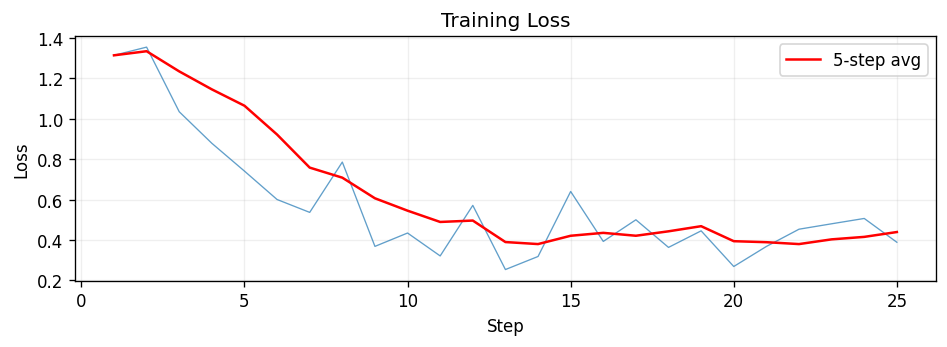

Plot saved to artifacts/texttosql_notebook_results.png


In [17]:
plot_path = Path("artifacts/texttosql_notebook_results.png")

initial_loss, final_loss = losses[0], losses[-1]
loss_drop_pct = (initial_loss - final_loss) / (abs(initial_loss) or 1.0) * 100
after_exact = eval_history[-1]["exact_match"]
after_similarity = eval_history[-1]["similarity"]

print(f"Loss:        {initial_loss:.4f} -> {final_loss:.4f}  ({loss_drop_pct:.0f}% drop)")
print(f"Exact match: {before_exact*100:.1f}% -> {after_exact*100:.1f}%")
print(f"Similarity:  {before_similarity*100:.1f}% -> {after_similarity*100:.1f}%")

# Single loss curve — the numbers above tell the eval story
fig, ax = plt.subplots(figsize=(8, 3))
loss_steps = list(range(1, len(losses) + 1))
ax.plot(loss_steps, losses, linewidth=0.8, alpha=0.7)
window = min(5, max(1, len(losses) // 4))
smoothed = pd.Series(losses).rolling(window, min_periods=1).mean()
ax.plot(loss_steps, smoothed, color="red", linewidth=1.5, label=f"{window}-step avg")
ax.set(xlabel="Step", ylabel="Loss", title="Training Loss")
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Plot saved to {plot_path}")

In [18]:
after_exact, after_similarity, _ = run_eval("final", eval_examples)

print(f"Final — Exact match: {after_exact*100:.1f}%  |  Similarity: {after_similarity*100:.1f}%")
print(f"Baseline was — Exact match: {before_exact*100:.1f}%  |  Similarity: {before_similarity*100:.1f}%\n")

# Compare the same held-out rows before and after training
_, _, comparison_after_df = run_eval("comparison_after", comparison_examples)
print("Before vs. after on held-out examples:")
show_eval_comparison("", comparison_before_df, comparison_after_df)

Final — Exact match: 50.0%  |  Similarity: 87.2%
Baseline was — Exact match: 0.0%  |  Similarity: 13.4%

Before vs. after on held-out examples:



,question,target_sql,base_output,trained_output,base_exact,trained_exact
0,What is the average rating of hotels in 'Asia'...,SELECT AVG(rating) FROM hotels WHERE region = ...,"Given the <USER_QUERY> and the <SCHEMA>, gener...",SELECT AVG(rating) FROM hotels WHERE region = ...,False,True
1,Insert a new space mission record for the 'Apo...,"INSERT INTO SpaceMissions (MissionID, MissionN...","Given the <USER_QUERY> and the <SCHEMA>, gener...","INSERT INTO SpaceMissions (MissionID, MissionN...",False,True


## Try it yourself

The trained adapter is still live on the server. Each call below creates a fresh snapshot and samples from it — edit the schema, change the questions, re-run as many times as you like. You could also go back and sample from the `"pre_training"` snapshot to see how far the model has come.

In [19]:
PLAYGROUND_SCHEMA = """
CREATE TABLE employees (
    id INT PRIMARY KEY,
    name VARCHAR(100),
    department VARCHAR(50),
    salary DECIMAL(10,2),
    hire_date DATE
);
""".strip()

PLAYGROUND_QUESTIONS = [
    "What are the names and salaries of employees in the Engineering department, ordered by salary descending?",
    "How many employees were hired after 2023-01-01?",
    "What is the average salary by department?",
]


def sample_sql(question, schema, sampler_name="interactive"):
    prompt_text = tokenizer.apply_chat_template(
        [{"role": "user", "content": PROMPT_TEMPLATE.format(question=question, context=schema)}],
        tokenize=False,
        add_generation_prompt=True,
    )
    prompt_ids = tokenizer.encode(prompt_text, add_special_tokens=False)
    sampler = create_sampler(sampler_name)
    result = sampler.sample(
        prompt=types.ModelInput.from_ints(tokens=prompt_ids),
        num_samples=1,
        sampling_params=types.SamplingParams(max_tokens=EVAL_MAX_TOKENS, temperature=0.0),
    ).result()
    return decode_first_sequence(result).strip()


print(f"Schema:\n{PLAYGROUND_SCHEMA}\n")

rows = [
    {"question": q, "generated_sql": sample_sql(q, PLAYGROUND_SCHEMA) or "-- empty --"}
    for q in PLAYGROUND_QUESTIONS
]
display(pd.DataFrame(rows))

Schema:
CREATE TABLE employees (
    id INT PRIMARY KEY,
    name VARCHAR(100),
    department VARCHAR(50),
    salary DECIMAL(10,2),
    hire_date DATE
);



,question,generated_sql
0,What are the names and salaries of employees i...,"SELECT name, salary FROM employees WHERE depar..."
1,How many employees were hired after 2023-01-01?,SELECT COUNT(DISTINCT hire_date) FROM employee...
2,What is the average salary by department?,"SELECT department, AVG(salary) as avg_salary F..."


## Configuration reference

All tunables in one place. Change values here and re-run the notebook from the top to experiment.

In [20]:
@dataclass
class Config:
    """Reference of every tunable used in this notebook."""
    base_model: str = "google/gemma-3-1b-pt"
    tokenizer_model: str = "google/gemma-3-1b-it"
    steps: int = 25
    batch_size: int = 8
    lora_rank: int = 16
    learning_rate: float = 2e-4
    grad_clip_norm: float = 0.3
    max_seq_length: int = 512
    eval_max_tokens: int = 256
    eval_every: int = 12
    train_limit: int = 10_000
    eval_limit: int = 5
    seed: int = 30
    base_url: str = "http://127.0.0.1:9003"
    metrics_path: str = "artifacts/texttosql_notebook_metrics.jsonl"
    plot_path: str = "artifacts/texttosql_notebook_results.png"

config = Config()
display(pd.DataFrame.from_dict(asdict(config), orient="index", columns=["value"]))

,value
base_model,google/gemma-3-1b-pt
tokenizer_model,google/gemma-3-1b-it
steps,25
batch_size,8
lora_rank,16
learning_rate,0.0002
grad_clip_norm,0.3
max_seq_length,512
eval_max_tokens,256
eval_every,12


## Next steps

- **More steps** — increase `steps` to 100+ and watch loss continue to drop. Adjust `eval_every` accordingly.
- **Hyperparameter sweeps** — try different `lora_rank`, `learning_rate`, and `batch_size` values. The Config reference above has all the knobs.
- **Pig Latin notebook** — see the [Pig Latin SFT notebook](piglatin_sft_notebook.ipynb) for a simpler task that runs faster and is good for quick iteration.
- **RLVR** — once SFT gives a reasonable starting point, the next step is reinforcement learning from verifiable rewards. Open-RL supports the same `forward_backward` / `optim_step` loop with reward-based objectives.
- **Larger models** — swap `gemma-3-1b-pt` for a larger checkpoint. The API calls stay the same; only the server config changes.